In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

from pathlib import Path


# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"


_Tratando dados e criando dataframes_

In [3]:
#Lendo o arquivo
employment_rate = pd.read_csv(DADOS/"employment_rate_japan.csv")
print('Informações da base de dados(dado:Taxa de emprego no Japão)')
print(employment_rate.info())

#Tirar o -01-01
employment_rate["observation_date"] = employment_rate['observation_date'].astype(str).str[:4].astype(int)
#Mudar nome das colunas
employment_rate = employment_rate.rename(columns= {'observation_date':'Year', 'LREM64TTJPM156S': 'taxa de emprego'})

#Mudar taxa para decimal
employment_rate["taxa de emprego"] = employment_rate['taxa de emprego'] 

#Selecionando o período necessário
employment_rate = employment_rate[(employment_rate["Year"] >= 1993) & (employment_rate['Year']<= 2019)]



Informações da base de dados(dado:Taxa de emprego no Japão)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  57 non-null     object 
 1   LREM64TTJPM156S   56 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.0+ KB
None


In [4]:
#Objetivo aqui é transformar os dados de hiato de produto em um dataframe para melhor trabalhar com os dados
data_gap = pd.read_excel(DADOS/"gap.xlsx", header=2)
print('Informações da base de dados(Dado: Output Gap Japão):')
print(data_gap.info())
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, selecionamos  apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Aqui mudamos o nome da coluna para "Year" e transformamos o ano em em int
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano = gap_ano.rename(columns={'Quarterly':'Year'})
#Selecionando o período desejado
gap_ano = gap_ano[(gap_ano["Year"]>= 1993) & (gap_ano["Year"]<= 2019)]



Informações da base de dados(Dado: Output Gap Japão):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Quarterly                          174 non-null    object 
 1   Output gap                         174 non-null    object 
 2   Capital input gap                  174 non-null    object 
 3   Labor input gap                    174 non-null    object 
 4   Tankan factor utilization index    93 non-null     object 
 5   Tankan factor utilization index.1  55 non-null     object 
 6   Unnamed: 6                         0 non-null      float64
 7   Beveridge ratio                    167 non-null    object 
 8   Tankan employment conditions DI    92 non-null     object 
 9   Tankan employment conditions DI.1  78 non-null     object 
 10  Unemployment rate                  167 non-null    object 
 11  Empl

C:\Users\tgu12\AppData\Local\Temp\ipykernel_21480\3367234328.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)


In [13]:
#Transformando em um data frame apenas
df_combinado = pd.merge(gap_ano, employment_rate, on='Year', how='inner')
df_combinado.head()

# converte a coluna para tipo numérico
df_combinado["Output gap"] = pd.to_numeric(df_combinado["Output gap"], errors='coerce')
df_combinado["taxa de emprego"] = pd.to_numeric(df_combinado["taxa de emprego"], errors='coerce')

# Coloca a taxa de emprego entre 0 e 1, porcentagem
df_combinado["taxa de emprego"] = df_combinado["taxa de emprego"]/100

print("Estatísticas da taxa de emprego em porcentagem")
df_combinado['taxa de emprego'].describe()


Estatísticas da taxa de emprego em porcentagem


count    27.000000
mean      0.709346
std       0.025657
min       0.683137
25%       0.692980
50%       0.700652
75%       0.713148
max       0.778133
Name: taxa de emprego, dtype: float64

_Gráficos_

In [12]:
print(df_combinado['taxa de emprego'].info())
print(df_combinado['Output gap'].info())



<class 'pandas.core.series.Series'>
RangeIndex: 27 entries, 0 to 26
Series name: taxa de emprego
Non-Null Count  Dtype  
--------------  -----  
27 non-null     float64
dtypes: float64(1)
memory usage: 348.0 bytes
None
<class 'pandas.core.series.Series'>
RangeIndex: 27 entries, 0 to 26
Series name: Output gap
Non-Null Count  Dtype  
--------------  -----  
27 non-null     float64
dtypes: float64(1)
memory usage: 348.0 bytes
None


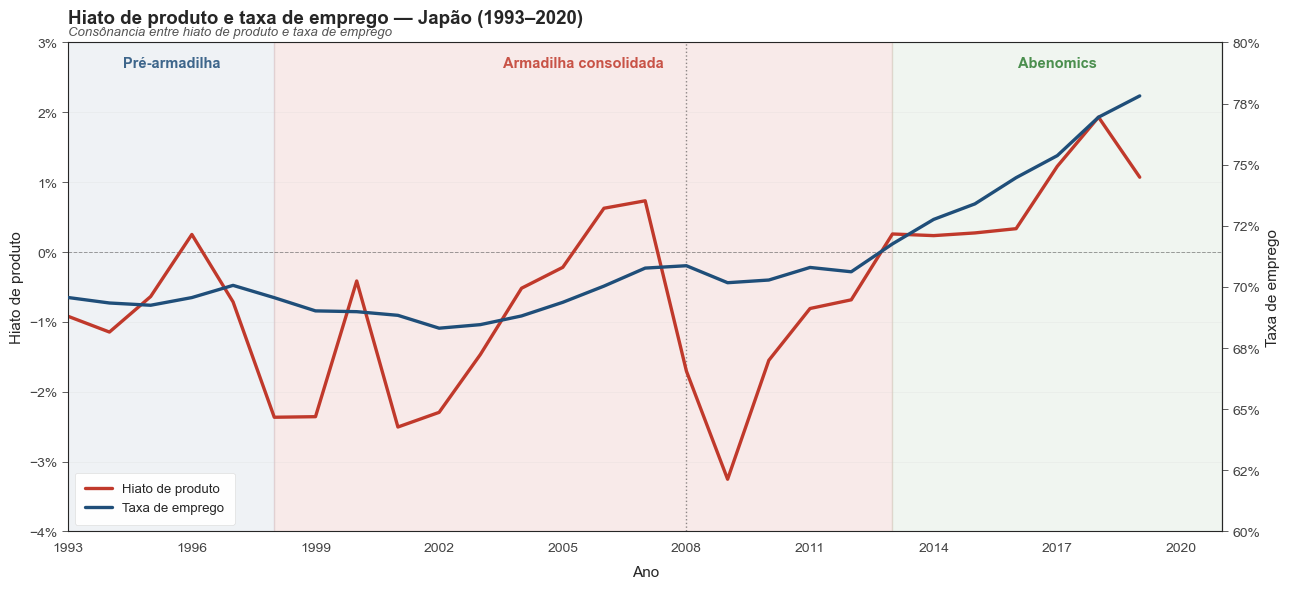

In [ ]:
#Criando gráfico
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 9,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

COR_GAP = '#c0392b'
COR_EMP = '#1f4e79'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax2 = ax.twinx()   

# faixas de fundo
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,   zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32', zorder=0)

#Ajustando os eixos
ax.set_ylim(-4, 3)
# ajuste à faixa real da taxa de emprego
ax2.set_ylim(60, 80)        
ax.set_xlim(1993, 2021)

# Rótulos dos períodos
y_label = 2.65
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

# linha do zero e marcação de 2008
ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -4.5), xytext=(2008.5, -5.4),
            fontsize=8.5, ha='left', va='center', color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Linhas representando as variáveis ao longo do tempo
l1 = ax.plot(df_combinado['Year'], df_combinado['Output gap'], linewidth=2.4,
             color=COR_GAP, zorder=3, label='Hiato de produto')
l2 = ax2.plot(df_combinado['Year'], df_combinado['taxa de emprego'] * 100, linewidth=2.4,
              color=COR_EMP, zorder=3, label='Taxa de emprego')

#Colocando os números dos eixos como porcentagem, ajustando as legendas, cor e etc.
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(1993, 2022, 3))

# Nome dos eixos e títulos
ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('Hiato de produto', fontsize=11)
ax2.set_ylabel('Taxa de emprego', fontsize=11)
ax.set_title('Hiato de produto e taxa de emprego — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'Consônancia entre hiato de produto e taxa de emprego',
        transform=ax.transAxes, fontsize=9.5, style='italic', color='#555', ha='left')

#legenda única juntando as duas linhas
linhas = l1 + l2
legend = ax.legend(linhas, [l.get_label() for l in linhas], loc='lower left',
                   framealpha=0.95, fontsize=9.5, frameon=True,
                   edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

#Grade horizontal
ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

#Marcações dos eixos em cinza
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.tick_params(colors='#444', length=4, width=0.6)
ax2.tick_params(colors='#444', length=4, width=0.6)

#Salvando a figura
plt.tight_layout()
plt.savefig(FIGURAS / 'output_X_taxaemprego.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()


In [38]:


# Carrega o arquivo CSV enviado
infl = pd.read_csv(DADOS/'growth_consumer_price.csv')

#  Renomeia a coluna de código técnico para 'Inflacao'
infl= infl.rename(columns={'CPALTT01JPQ657N': 'Inflacao'})

# Garante que a coluna de data está no formato correto (datetime)
infl['observation_date'] = pd.to_datetime(infl['observation_date'])



#  Renomeia a coluna 'observation_date' para 'Year' e extrai apenas o ano
infl = infl.rename(columns={'observation_date': 'Year'})
infl['Year'] = infl['Year'].dt.year
#Coloca year em int, para o gráfico
infl['Year'] = infl['Year'].astype(int)
#Tira as linhas sem dados
infl = infl.dropna(subset=['Inflacao'])
infl.head()



,Year,Inflacao
0,1956,0.501253
1,1957,-1.370332
2,1958,0.104275
3,1959,0.894393
4,1960,0.630810


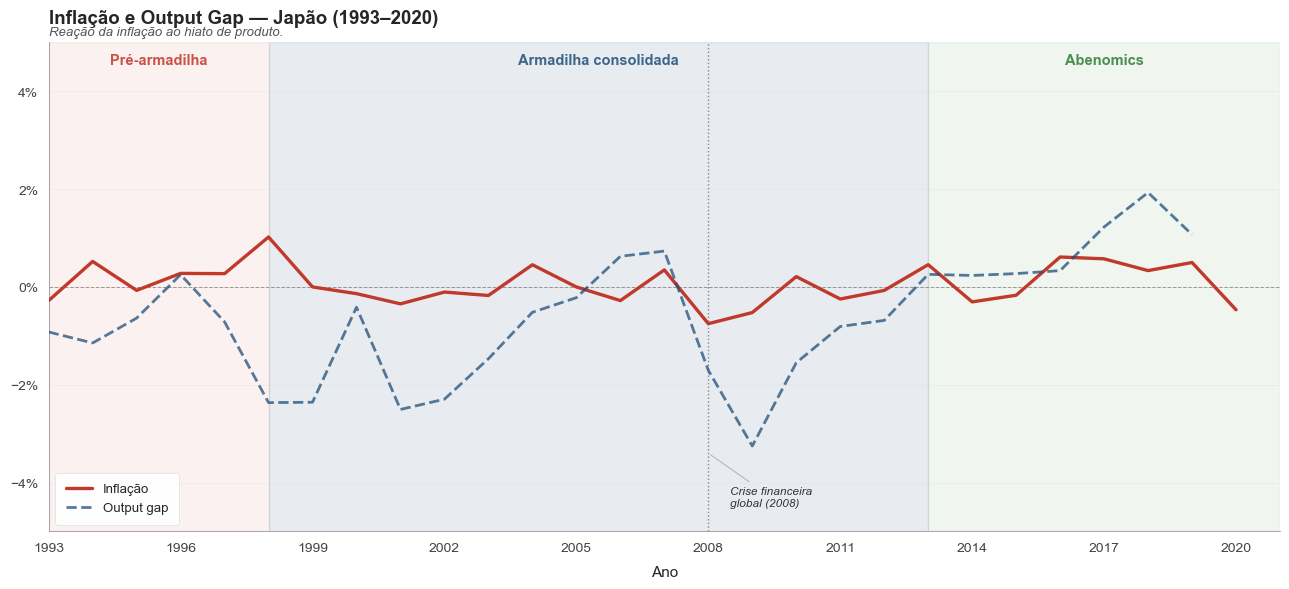

In [41]:

# Estilo Geral e Configurações

sns.set_style('white')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Garantindo que os valores da coluna Year são do tipo int em ambos os DataFrames
infl['Year']    = infl['Year'].astype(int)
gap_ano['Year'] = gap_ano['Year'].astype(int)

# Paleta de Cores 
COR_INFLACAO = '#c0392b' 
COR_GAP      = '#1f4e79'  


# Estrutura do Gráfico

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')  # Fundo branco

#Sombreamento dos três períodos
ax.axvspan(1993, 1998, alpha=0.07, color=COR_INFLACAO, zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,      zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32',   zorder=0)

# Limites e títulos dos períodos
ax.set_ylim(-5, 5)
ax.set_xlim(1993, 2021)

# Adiciona os títulos  no topo de cada período
y_label = 4.55
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color=COR_INFLACAO, weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

# Linha do zero 
ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)


# Faz o merge para alinhar os anos da inflação e do gap
df_junto = infl.merge(gap_ano, on='Year', how='inner')



# L1 = Linha da Inflação 
sns.lineplot(data=infl, x='Year', y='Inflacao',
             label='Inflação',
             linewidth=2.4, color=COR_INFLACAO, ax=ax, zorder=3)

# L2 = Linha do Output Gap 
sns.lineplot(data=gap_ano, x='Year', y='Output gap',
             label='Output gap',
             linewidth=2.0, color=COR_GAP, alpha=0.75,
             linestyle='--', ax=ax, zorder=3)


# 4. Formatação dos Eixos e enfeites


# Eixo Y em formato de porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Define a escala do eixo X para saltar de 3 em 3 anos
ax.set_xticks(range(1993, 2022, 3))

# Título dos eixos e título principal
ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11) 
ax.set_title('Inflação e Output Gap — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

# Subtítulo 
ax.text(0.0, 1.015,
        'Reação da inflação ao hiato de produto.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

# Legenda posicionada no canto inferior esquerdo
legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

# Linhas de grade horizontais discretas 
ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

# Remove as bordas superior e direita 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customiza as bordas esquerda e inferior
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

# Tracinhos dos eixos discretos
ax.tick_params(colors='#444', length=4, width=0.6)

# Marcador da crise financeira global de 2008
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -3.4), xytext=(2008.5, -4.3),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Ajuste  de layout e salvamento da imagem
plt.tight_layout()
plt.savefig(FIGURAS/'inflacao_e_gap_japao.png', dpi=200,
            bbox_inches='tight', facecolor='white')

plt.show()